In [23]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [24]:
df = pd.read_csv("results.csv")
dfs = {k: v.copy() for k, v in df.groupby('DS_Name')}

In [25]:
df

,DS_Name,Operacion,TamanoDatos,Tiempo_Ejecucion_ns
0,SingleLLNoTail,PushFront,10,4446
1,SingleLLNoTail,PushBack,10,8100
2,SingleLLNoTail,isEmpty,10,5100
3,SingleLLNoTail,AddAfter,10,10928
4,SingleLLNoTail,AddBefore,10,4568
...,...,...,...,...
1051,Stack,Pop,100000000,3911
1052,Stack,Delete,100000000,29976512
1053,Stack,Peek,100000000,1560
1054,Stack,Size,100000000,2235


In [26]:
with pd.ExcelWriter("resultados.xlsx", engine="openpyxl") as writer:
    for nombre_estructura, df_sub in dfs.items():
        mask = np.log10(df_sub[" TamanoDatos"]) % 1 == 0
        df_filtrado = df_sub[mask]

        df_pivot = df_filtrado.pivot_table(
            index=" TamanoDatos",
            columns=" Operacion",
            values=" Tiempo_Ejecucion_ns"
        ).reset_index()
        
        df_pivot.to_excel(writer, sheet_name=nombre_estructura, index=False)

In [27]:
nombres = {"DoublyLLNoTail": "Doubly Linked Lists (No Tail)", 
           "DoublyLLWithTail" : "Doubly Linked Lists (With Tail)", 
           "Queue" : "Queue", 
           "SingleLLNoTail" : "Linked List (No Tail)", 
           "SingleLLWithTail" : "Linked List (With Tail)",
           "Stack" : "Stack"}

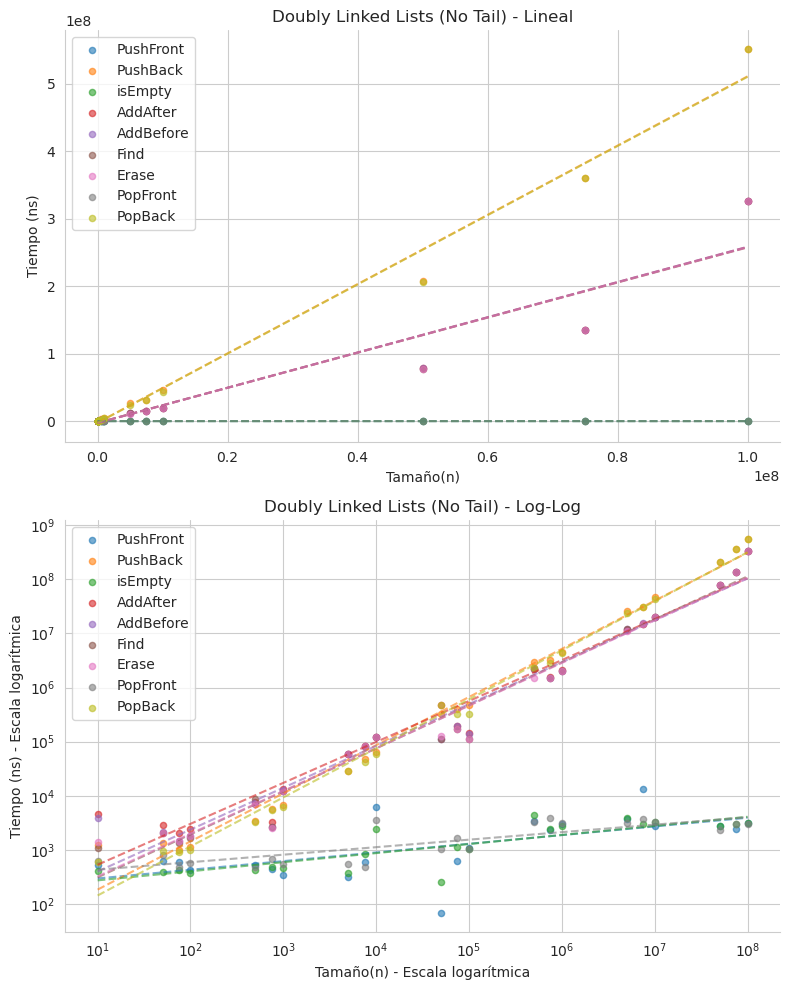

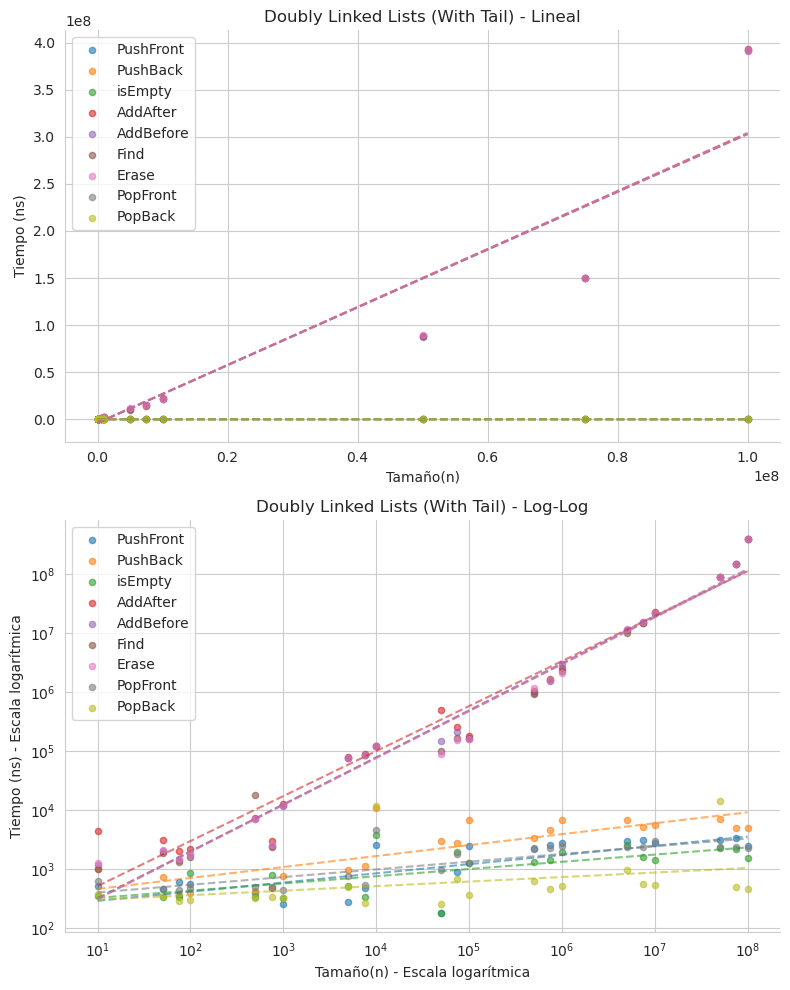

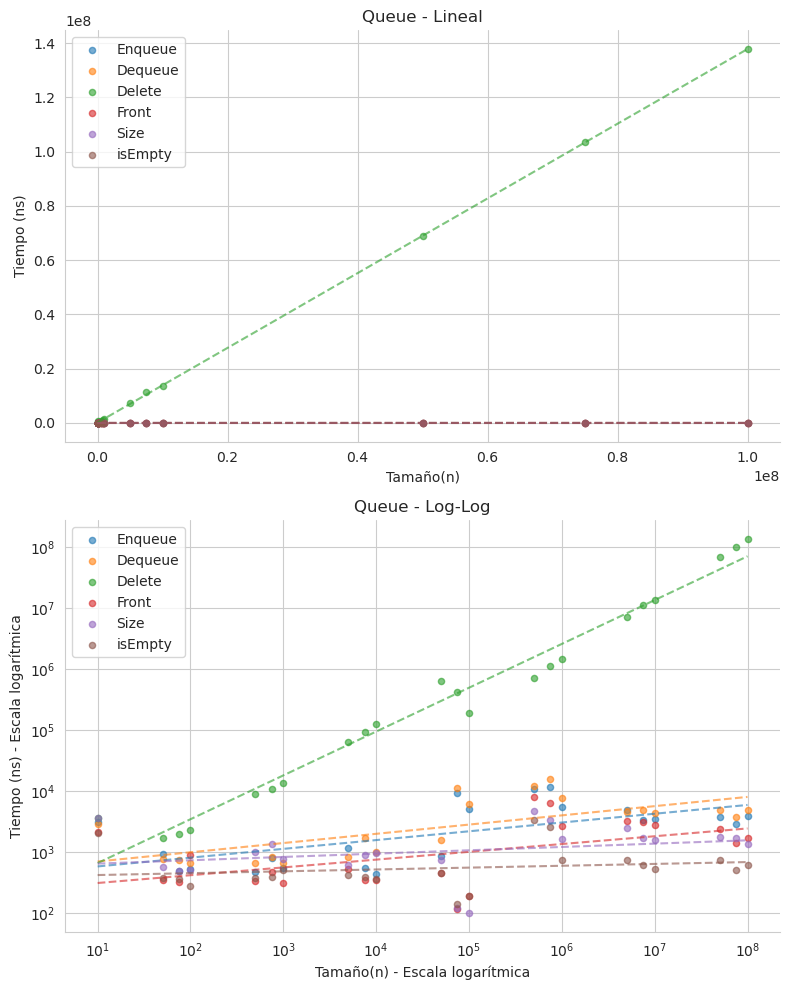

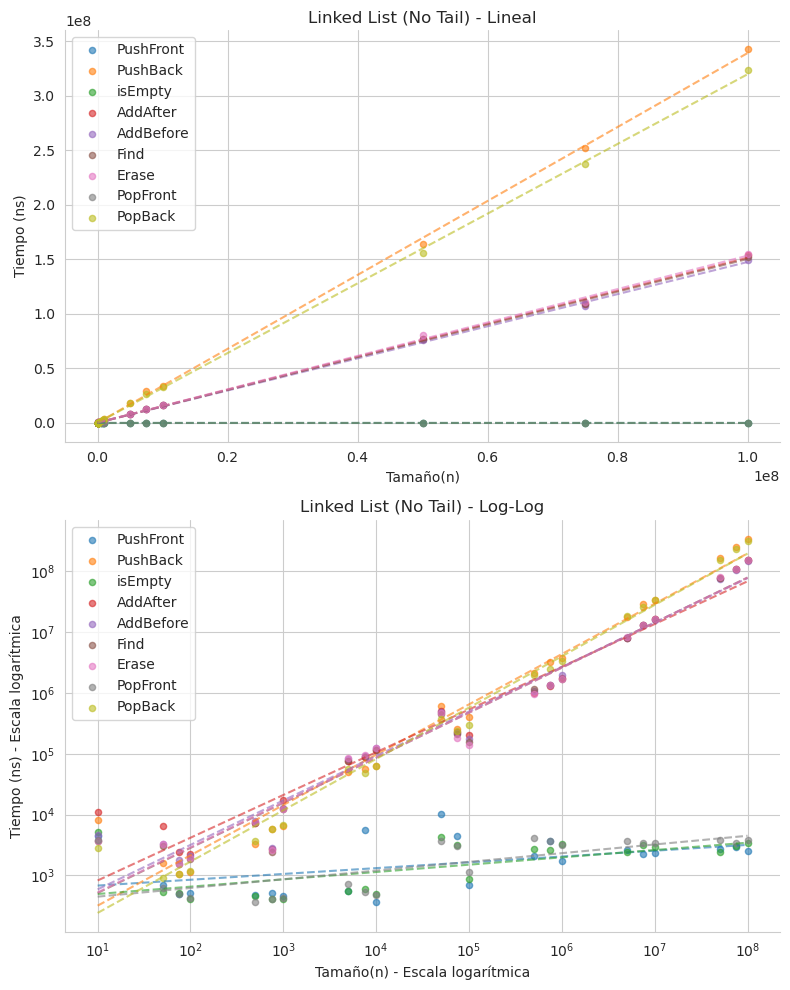

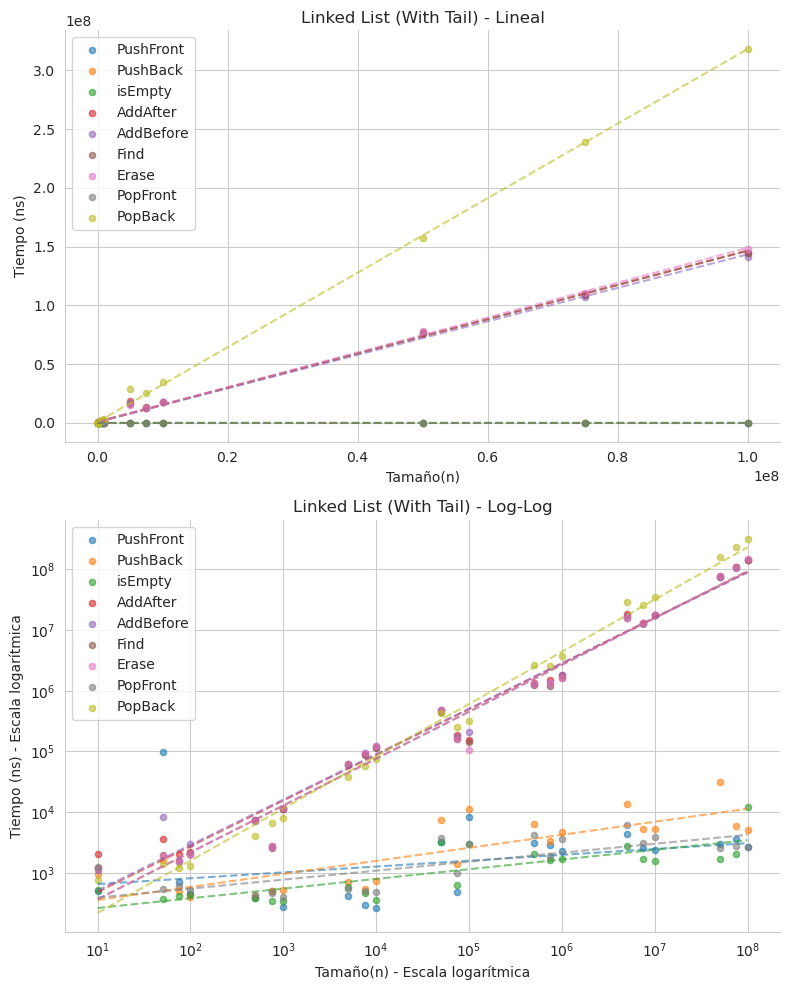

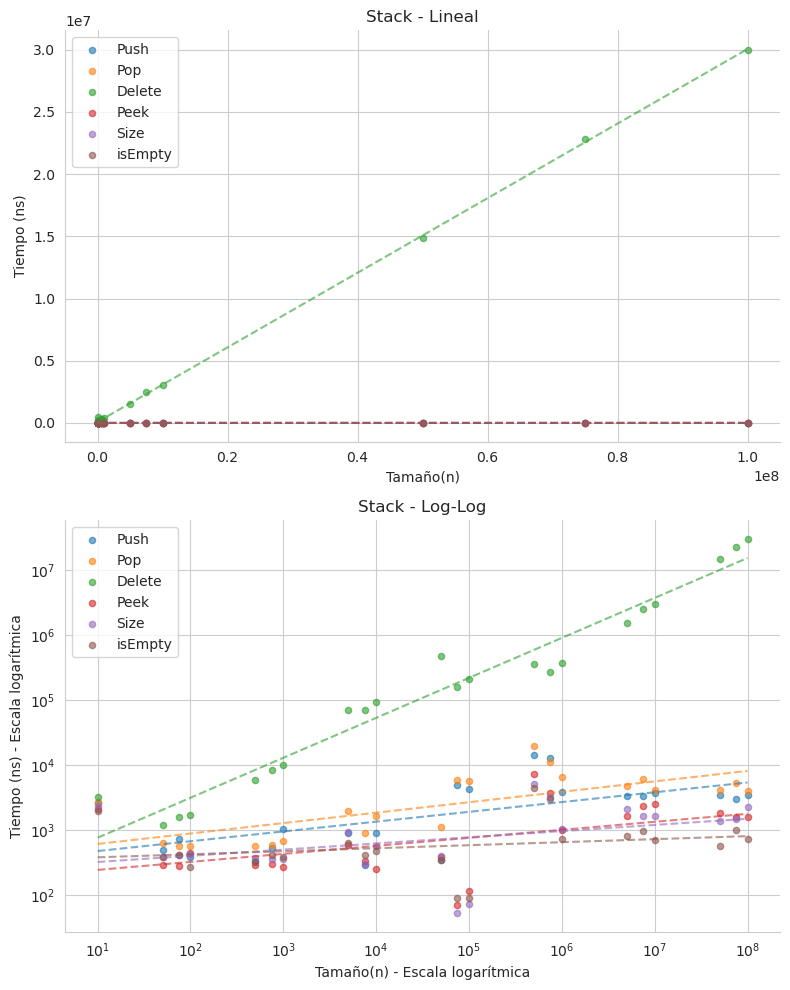

In [28]:
sns.set_style("whitegrid")

resultados = []
x = dfs["DoublyLLNoTail"][" TamanoDatos"].unique()

for nombre_estructura, df_sub in dfs.items():
    results = {}

    fig, axes = plt.subplots(2, 1, figsize=(8, 10), sharex=False)

    for op in df_sub[" Operacion"].unique():
        y = df_sub.loc[df_sub[" Operacion"] == op, " Tiempo_Ejecucion_ns"].values

        #Ajuste lineal
        coeffs = np.polyfit(x, y, 1)
        pendiente = coeffs[0]
        y_pred = np.polyval(coeffs, x)

        mean_y = np.mean(y)

        # R2
        r2 = 1 - np.sum((y - y_pred)**2)/np.sum((y - mean_y)**2)

        std_y = np.std(y)
        cv = std_y / mean_y if mean_y != 0 else 0

        resultados.append({
            "estructura": nombre_estructura,
            "operacion": op,
            "r2": r2,
            "pendiente": pendiente,
            "cv": cv
        })

        # Ajuste logarítmico
        log_x = np.log(x)
        log_y = np.log(y)

        coeffs_log = np.polyfit(log_x, log_y, 1)
        k, log_c = coeffs_log
        y_pred_log = np.exp(log_c) * x**k

        results[op] = {
            "y": y,
            "y_pred": y_pred,
            "y_pred_log": y_pred_log
        }

    # --- plotting ---
    for op, data in results.items():
        # linear plot
        axes[0].scatter(x, data["y"], s=20, alpha=0.6, label=op)
        axes[0].plot(x, data["y_pred"], linestyle="--", alpha=0.6)

        # log-log plot
        axes[1].scatter(x, data["y"], s=20, alpha=0.6, label=op)
        axes[1].plot(x, data["y_pred_log"], linestyle="--", alpha=0.6)

    # scales
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")

    axes[0].set_title(f"{nombres[nombre_estructura]} - Lineal")
    axes[1].set_title(f"{nombres[nombre_estructura]} - Log-Log")

    axes[0].legend()
    axes[1].legend()

    axes[0].set_xlabel("Tamaño(n)")
    axes[0].set_ylabel("Tiempo (ns)")

    axes[1].set_xlabel("Tamaño(n) - Escala logarítmica")
    axes[1].set_ylabel("Tiempo (ns) - Escala logarítmica")

    sns.despine()
    plt.tight_layout()
    plt.show()

# --- export to DataFrames ---
resultados = pd.DataFrame(resultados)
 

In [29]:
resultados

,estructura,operacion,r2,pendiente,cv
0,DoublyLLNoTail,PushFront,0.019784,0.000015,1.266393
1,DoublyLLNoTail,PushBack,0.989206,5.134538,2.437989
2,DoublyLLNoTail,isEmpty,0.179681,0.000022,0.784773
3,DoublyLLNoTail,AddAfter,0.908908,2.609844,2.686078
4,DoublyLLNoTail,AddBefore,0.908983,2.611801,2.688703
5,DoublyLLNoTail,Find,0.908386,2.602101,2.689641
6,DoublyLLNoTail,Erase,0.908167,2.606605,2.700193
7,DoublyLLNoTail,PopFront,0.116074,0.000017,0.687582
8,DoublyLLNoTail,PopBack,0.988891,5.131023,2.453151
9,DoublyLLWithTail,PushFront,0.225726,0.000021,0.731375
